In [2]:
# 라이브러리 기본 참조
from hossam import load_data
from pandas import DataFrame, melt
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np
# 선형회귀를 위한 참조
import statsmodels.api as sm
from statsmodels.formula.api import ols
# 결과 검정을 위한 참조
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, probplot, shapiro, anderson
from statsmodels.stats.api import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
# VIF값을 계산하기 위한 참조
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐 방지

In [4]:
origin = load_data('diamonds')
origin

[data] https://data.hossam.kr/data/lab12_/diamonds.xlsx
[desc] 다이아몬드를 커팅, 색상, 투명도, 가격 및 기타 속성을 기준으로 분석합니다. (출처: https://www.kaggle.com/datasets/shivam2503/diamonds)

field    description
-------  -------------------------------------------------------------------------------------------------
price    price in US dollars ($326 ~ $18,823)
carat    weight of the diamond (0.2~5.01)
cut      quality of the cut (Fair, Good, Very Good, Premium, Ideal)
color    diamond colour, from J (worst) to D (best)
clarity  a measurement of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
x        length in mm (0~10.74)
y        width in mm (0--58.9)
z        depth in mm (0--31.8)
depth    total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79)
table    width of top of diamond relative to widest point (43--95)



,price,carat,cut,color,clarity,x,y,z,depth,table
0,326,0.23,Ideal,E,SI2,3.95,3.98,2.43,61.5,55.0
1,326,0.21,Premium,E,SI1,3.89,3.84,2.31,59.8,61.0
2,327,0.23,Good,E,VS1,4.05,4.07,2.31,56.9,65.0
3,334,0.29,Premium,I,VS2,4.20,4.23,2.63,62.4,58.0
4,335,0.31,Good,J,SI2,4.34,4.35,2.75,63.3,58.0
...,...,...,...,...,...,...,...,...,...,...
53935,2757,0.72,Ideal,D,SI1,5.75,5.76,3.50,60.8,57.0
53936,2757,0.72,Good,D,SI1,5.69,5.75,3.61,63.1,55.0
53937,2757,0.70,Very Good,D,SI1,5.66,5.68,3.56,62.8,60.0
53938,2757,0.86,Premium,H,SI2,6.15,6.12,3.74,61.0,58.0


x,y,z에 빈 값 있는지 확인<br>
이상치 확인

In [5]:
na_sum = origin[['x', 'y', 'z']].isna().sum()
len(na_sum)
print(f"빈값은 {na_sum}")
print(f"빈값 개수: {len(na_sum)}")


빈값은 x    0
y    0
z    0
dtype: int64
빈값 개수: 3


cut,color, clarity 품질 변수들이 몇 개의 범주들로 구성되어있을까?

In [6]:
print(f"""
cut 범주 수: {origin['cut'].nunique()}
color 범주 수: {origin['color'].nunique()}
clarity 범주 수: {origin['clarity'].nunique()}
""")



cut 범주 수: 5
color 범주 수: 7
clarity 범주 수: 8



빈도

In [7]:
origin['cut'].value_counts()
origin['color'].value_counts()
origin['clarity'].value_counts()


clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64

📝 미션 2. “가격 데이터는 어떤 모습일까?”

가격이 고르게 분포되어있을가?<br>
특정구간에 몰려있을까?

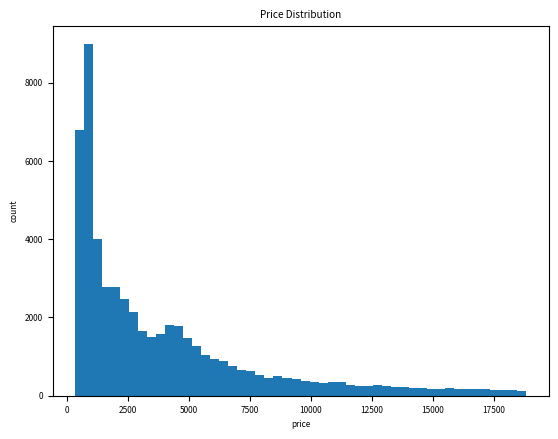

저가구간에 데이터가 집중, 고가 영역으로 갈수록 관측치가 급격히 줄어들어 오른쪽 꼬리가 긴 분포를 보인다.
 그리고, carat역시 작은 값에 집중되어 있어 특정 단위에서 관측치가 몰리는 계단형 분포를 보임.


In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(origin['price'], bins=50)
plt.title('Price Distribution')
plt.xlabel('price')
plt.ylabel('count')
plt.show()
print(f"저가구간에 데이터가 집중, 고가 영역으로 갈수록 관측치가 급격히 줄어들어 오른쪽 꼬리가 긴 분포를 보인다.\n 그리고, carat역시 작은 값에 집중되어 있어 특정 단위에서 관측치가 몰리는 계단형 분포를 보임.")

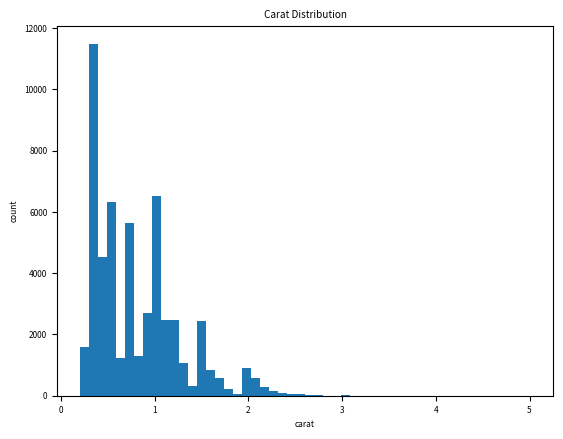

특정값에서 쏠림 현상이 발생했습니다.
즉, 스파이크 현상이 발생했다고 볼 수 있습니다.
또한, 작은 캐럿의 다이아몬드가 압도적으로 많은 것으로 확인되어 오른쪽으로 꼬리가 길다고 판단할 수 있습니다.
비대칭적 급락을 발견했습니다.
0.99캐럿에서 빈도수가 급격히 줄어드는 것을 알 수있습니다.
특정구간에서 빈도수가 집중되는 다봉형 패턴을 통해
 사람들의 선호도가 높은 특정 중량(0.5,1.0캐럿)에서 집중되었다는 것을 알 수 있습니다.
이를 통해, 시장 가격이 특정 중량을 기준으로 급등하기 때문에, 연마과정에서 의도적으로 해당 무게를 맞추려고 한 경향이 반영된 것으로 해석됩니다.


In [21]:
plt.figure()
plt.hist(origin['carat'], bins=50)
plt.title('Carat Distribution')
plt.xlabel('carat')
plt.ylabel('count')
plt.show()
print(f"특정값에서 쏠림 현상이 발생했습니다.\n즉, 스파이크 현상이 발생했다고 볼 수 있습니다.\n또한, 작은 캐럿의 다이아몬드가 압도적으로 많은 것으로 확인되어 오른쪽으로 꼬리가 길다고 판단할 수 있습니다.")
print(f"비대칭적 급락을 발견했습니다.\n0.99캐럿에서 빈도수가 급격히 줄어드는 것을 알 수있습니다.")
print(f"특정구간에서 빈도수가 집중되는 다봉형 패턴을 통해\n 사람들의 선호도가 높은 특정 중량(0.5,1.0캐럿)에서 집중되었다는 것을 알 수 있습니다.\n이를 통해, 시장 가격이 특정 중량을 기준으로 급등하기 때문에, 연마과정에서 의도적으로 해당 무게를 맞추려고 한 경향이 반영된 것으로 해석됩니다.")

로그 변환은 왜 등장할까?

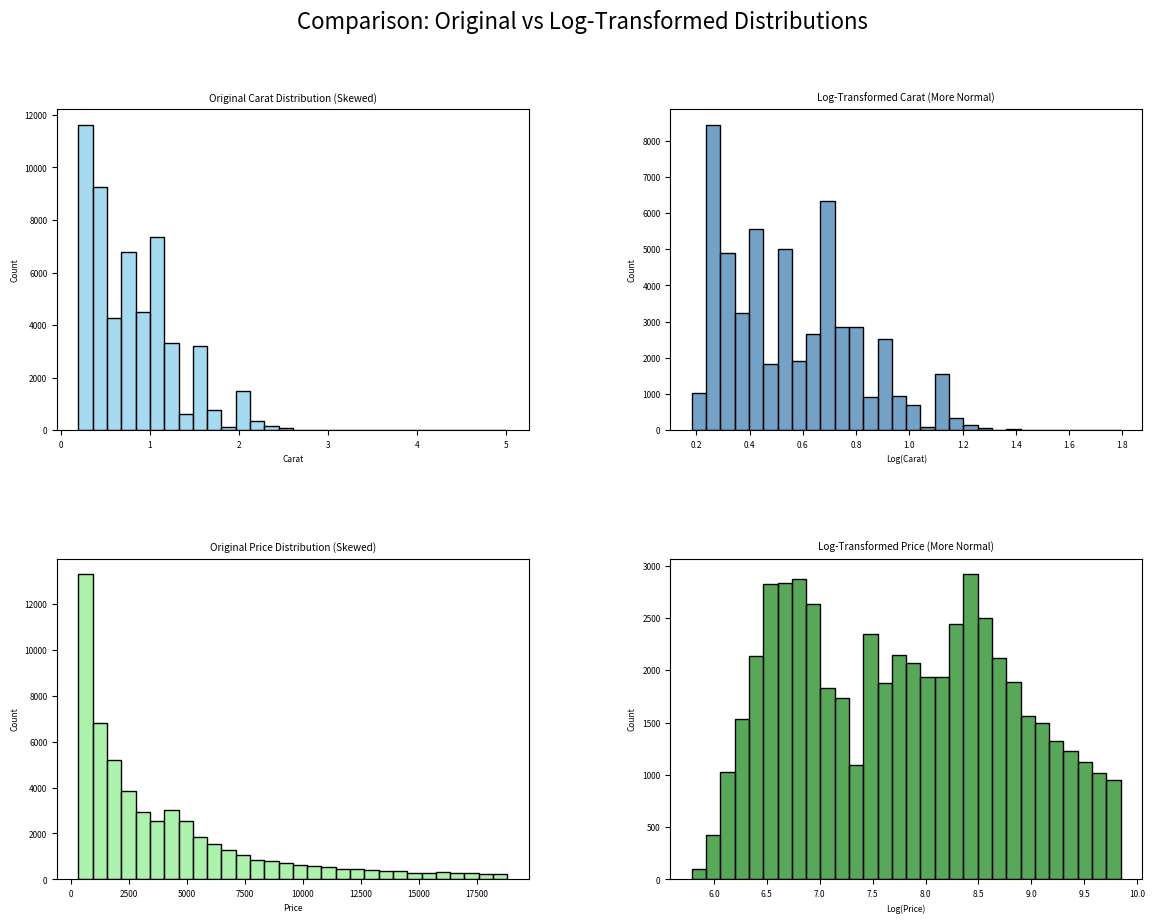

오른쪽으로 꼬리가 긴 것을 보아 carat중량이 작을수록 값이 크다는 것을 알게 됨.


In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. 데이터 로드 (seaborn 내장 데이터셋 활용)
# 만약 로컬 파일이 있다면: df = pd.read_csv('diamonds.csv')
try:
    df = sns.load_dataset('diamonds')
except:
    # 데이터셋 로드 실패 시 예시 데이터 생성 (실제 실행 시에는 이 부분은 무시됩니다)
    np.random.seed(42)
    n = 5000
    carat = np.random.exponential(scale=0.7, size=n) + 0.2
    price = 3000 * carat ** 2 + np.random.normal(0, 500, n)
    price = np.abs(price) + 100
    df = pd.DataFrame({'carat': carat, 'price': price})

# 2. 그래프 설정 (2행 2열)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3) # 그래프 간 간격 조정

# --- Carat 분포 비교 ---
# (1) 원본 Carat
sns.histplot(df['carat'], kde=False, bins=30, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Original Carat Distribution (Skewed)')
axes[0, 0].set_xlabel('Carat')

# (2) 로그 변환 Carat
# np.log1p는 log(1 + x)를 계산하여 0일 때 -inf가 나오는 것을 방지합니다.
sns.histplot(np.log1p(df['carat']), kde=False, bins=30, ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Log-Transformed Carat (More Normal)')
axes[0, 1].set_xlabel('Log(Carat)')

# --- Price 분포 비교 ---
# (3) 원본 Price
sns.histplot(df['price'], kde=False, bins=30, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Original Price Distribution (Skewed)')
axes[1, 0].set_xlabel('Price')

# (4) 로그 변환 Price
sns.histplot(np.log1p(df['price']), kde=False, bins=30, ax=axes[1, 1], color='forestgreen')
axes[1, 1].set_title('Log-Transformed Price (More Normal)')
axes[1, 1].set_xlabel('Log(Price)')

# 전체 제목
plt.suptitle('Comparison: Original vs Log-Transformed Distributions', fontsize=16)

# 그래프 표시
plt.show()
print(f"오른쪽으로 꼬리가 긴 것을 보아 carat중량이 작을수록 값이 크다는 것을 알게 됨.")

품질 등급은 가격을 얼마나 설명해줄까?

C:\Users\itwill\AppData\Local\Temp\ipykernel_22900\195751731.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cut', y='price', data=df, order=cut_order, ax=axes[0], palette='viridis')
C:\Users\itwill\AppData\Local\Temp\ipykernel_22900\195751731.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='color', y='price', data=df, order=color_order, ax=axes[1], palette='viridis')
C:\Users\itwill\AppData\Local\Temp\ipykernel_22900\195751731.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='clarity', y='price', data=df, order=clarity_

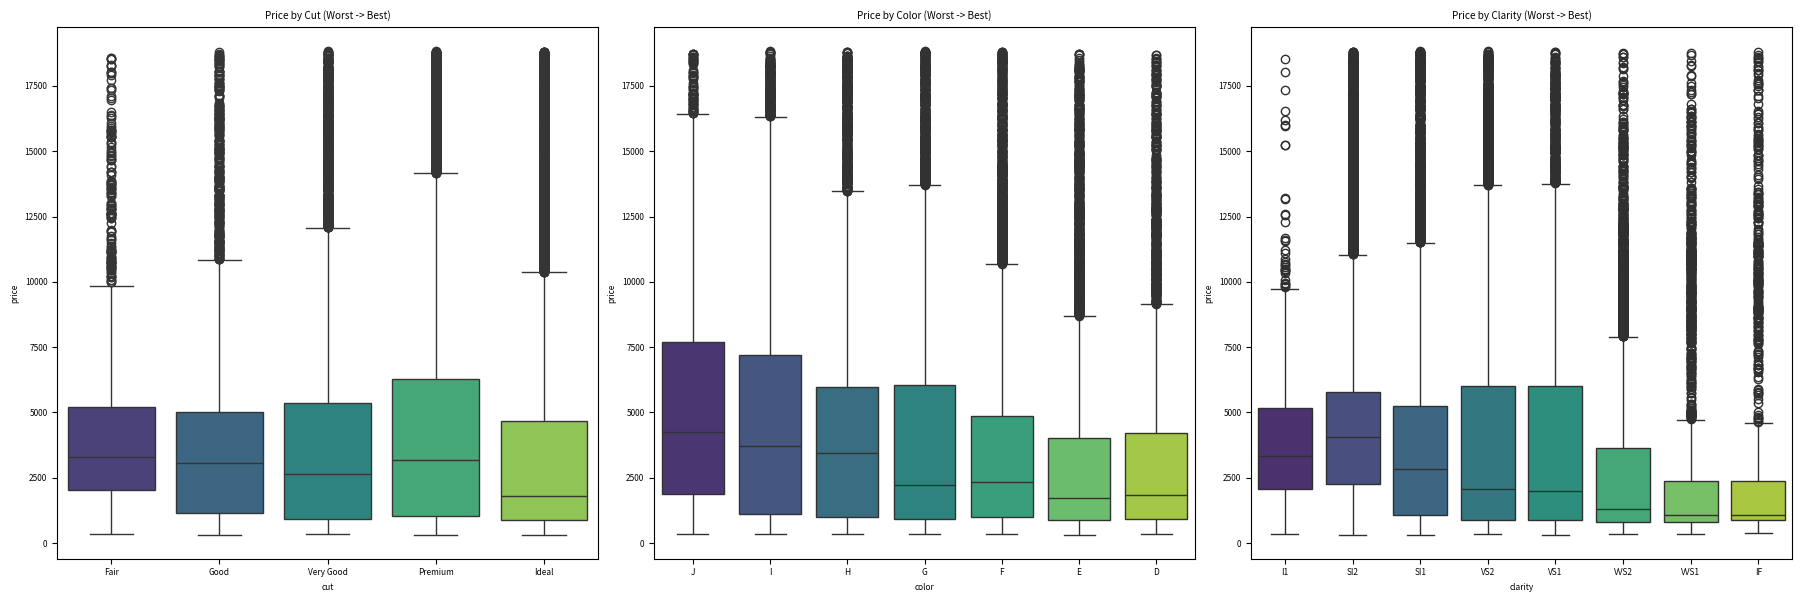

극과 극 차이가 엄청나다, 어떤 다이아몬드는 아주 싸고 어떤 것은 아주 비싸다
발견:Fair등급에는 작고 못난돌과 못 깎았지만 엄청 큰 돌이 뒤섞여 있음.
분포가 위 아래로 쫙 찢어지게 나타났음.즉, 가격이 특정 구간에 몰려있지 않고 가장 저가부터 초고가까지 매우 넓게 분포하고 있다.
성격이 균일하지 않고 잡탕이다.
또한, 예측하기 어렵다


In [35]:
# 1. Cut (컷): 못 깎은 것 -> 잘 깎은 것
# Fair가 제일 안 좋고, Ideal이 제일 좋습니다.
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']

# 2. Color (색상): 노란색(J) -> 투명색(D)
# J가 가장 노란끼가 돌고(나쁨), D가 가장 투명하고 비쌉니다(좋음).
# 알파벳 역순이라 헷갈리기 쉽습니다.
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']

# 3. Clarity (투명도/내포물): 내포물 많음(I1) -> 완전 무결(IF)
# I1은 눈에 보일 정도, IF는 현미경으로도 안 보이는 수준입니다.
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 로드
df = sns.load_dataset('diamonds')

# 그래프 그리기 준비
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# [핵심] order 파라미터에 위에서 만든 리스트를 넣어줍니다.
sns.boxplot(x='cut', y='price', data=df, order=cut_order, ax=axes[0], palette='viridis')
axes[0].set_title('Price by Cut (Worst -> Best)')

sns.boxplot(x='color', y='price', data=df, order=color_order, ax=axes[1], palette='viridis')
axes[1].set_title('Price by Color (Worst -> Best)')

sns.boxplot(x='clarity', y='price', data=df, order=clarity_order, ax=axes[2], palette='viridis')
axes[2].set_title('Price by Clarity (Worst -> Best)')

plt.tight_layout()
plt.show()

print(f"극과 극 차이가 엄청나다, 어떤 다이아몬드는 아주 싸고 어떤 것은 아주 비싸다")
print(f"발견:Fair등급에는 작고 못난돌과 못 깎았지만 엄청 큰 돌이 뒤섞여 있음.\n분포가 위 아래로 쫙 찢어지게 나타났음.즉, 가격이 특정 구간에 몰려있지 않고 가장 저가부터 초고가까지 매우 넓게 분포하고 있다.\n성격이 균일하지 않고 잡탕이다.\n또한, 예측하기 어렵다")

🍭특정구간에 따른 가격이 분포되어있는지 알아봤다.<br>
cut별로 분류해서 가격의 차이가 있는지 알아봤다.

color와 price끼리 매칭

In [25]:
# 필요한 컬럼만 선택
df = origin[['cut','price']].copy()

# 서열 매핑
clarity_order = {
    'ideal': 1, 'premium': 2, 'Verygood': 3,
    'Good': 4
}



df['cut'].map(clarity_order)


df.head()

,cut,price
0,Ideal,326
1,Premium,326
2,Good,327
3,Premium,334
4,Good,335


In [27]:
# 필요한 컬럼만 선택
df = origin[['cut','price','carat']].copy()

# 서열 매핑
clarity_order = {
    'ideal': 1, 'premium': 2, 'Verygood': 3,
    'Good': 4
}



df['cut'].map(clarity_order)


df.head()

,cut,price,carat
0,Ideal,326,0.23
1,Premium,326,0.21
2,Good,327,0.23
3,Premium,334,0.29
4,Good,335,0.31


C:\Users\itwill\AppData\Local\Temp\ipykernel_22900\3896063915.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cut', y='price', data=df, order=cut_order, ax=axes[0], palette='viridis')
C:\Users\itwill\AppData\Local\Temp\ipykernel_22900\3896063915.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='color', y='price', data=df, order=color_order, ax=axes[1], palette='viridis')
C:\Users\itwill\AppData\Local\Temp\ipykernel_22900\3896063915.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='clarity', y='price', data=df, order=clari

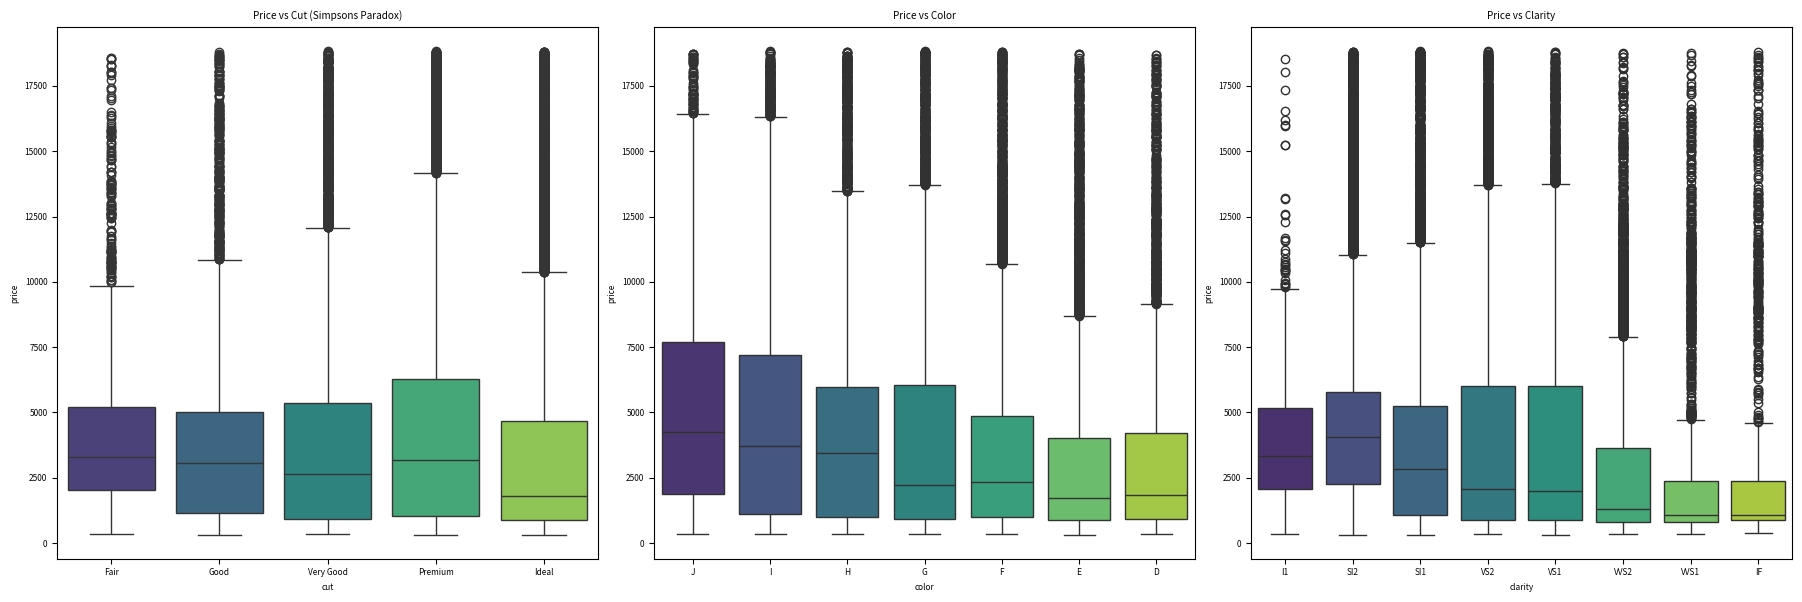

로그 변환된 예측값: 8.5
원래 가격으로 복원한 값: $4913.77


In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. 데이터 로드
try:
    df = sns.load_dataset('diamonds')
except:
    # 인터넷이 안 될 경우를 대비해 로컬 CSV 파일이 있다면 경로를 지정하세요.
    # df = pd.read_csv('diamonds.csv') 
    pass

# 2. 그래프 그리기 설정 (3개의 그래프를 나란히 배치)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 각 등급의 순서 정의 (나쁨 -> 좋음 순서)
# (분석할 때 순서가 뒤죽박죽되지 않게 지정해주는 것이 좋습니다)
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D'] # J가 가장 노랗고(나쁨), D가 투명함(좋음)
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'] # I1이 내포물 많음(나쁨)

# --- (1) Cut 등급별 가격 분포 ---
sns.boxplot(x='cut', y='price', data=df, order=cut_order, ax=axes[0], palette='viridis')
axes[0].set_title('Price vs Cut (Simpsons Paradox)')

# --- (2) Color 등급별 가격 분포 ---
sns.boxplot(x='color', y='price', data=df, order=color_order, ax=axes[1], palette='viridis')
axes[1].set_title('Price vs Color')

# --- (3) Clarity 등급별 가격 분포 ---
sns.boxplot(x='clarity', y='price', data=df, order=clarity_order, ax=axes[2], palette='viridis')
axes[2].set_title('Price vs Clarity')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# [보너스] 로그 변환된 값을 원래 가격으로 되돌리는 코드 예시
# ---------------------------------------------------------

# 예: 모델이 예측한 로그 가격이 8.5라고 가정
predicted_log_price = 8.5

# 복원: np.log1p로 변환했다면 np.expm1로 되돌립니다. (그냥 log면 exp 사용)
original_price = np.expm1(predicted_log_price)

print(f"로그 변환된 예측값: {predicted_log_price}")
print(f"원래 가격으로 복원한 값: ${original_price:.2f}")

컷 등급이 Good인 경우 시각적으로 느낄 수 있는 밝기,파이어, 반짝임 등이 VeryGood에 해당.\n
트리플엑설런트\n


낮은 투명도일수록 가격이 낮을까?

🍭전처리

price,clarity,color 매칭<br>
map()이용

In [9]:
import pandas as pd

# 필요한 컬럼만 선택
df = origin[['price', 'clarity', 'color']].copy()

# 서열 매핑
clarity_order = {
    'I1': 1, 'SI2': 2, 'SI1': 3,
    'VS2': 4, 'VS1': 5,
    'VVS2': 6, 'VVS1': 7,
    'IF': 8
}

color_order = {
    'J': 1, 'I': 2, 'H': 3,
    'G': 4, 'F': 5, 'E': 6, 'D': 7
}

df['clarity_ord'] = df['clarity'].map(clarity_order)
df['color_ord'] = df['color'].map(color_order)

df.head()


,price,clarity,color,clarity_ord,color_ord
0,326,SI2,E,2,6
1,326,SI1,E,3,6
2,327,VS1,E,5,6
3,334,VS2,I,4,2
4,335,SI2,J,2,1


color를 통제(매칭)했을 때, clarity가 높을수록(price ↑) 가격이 상승할 것이다.